<a href="https://colab.research.google.com/github/schere3/app1/blob/main/RodriguezRoca_Scherezade_tfmicro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROYECTO FINAL : Segmentación de Clientes (Customer Segmentation)**
**Objetivo:** Agrupar una base de datos de clientes en diferentes "perfiles" o clústeres según sus hábitos de compra. Útil para estrategias de marketing personalizadas.



# **1. Configuración del Proyecto y Adquisición de Datos**
## **1.1 Importación de Librerías y Dependencias**

En esta sección se cargan las herramientas necesarias para el procesamiento numérico, la manipulación de DataFrames, la visualización de datos y los algoritmos de Machine Learning.


In [ ]:
# librerías para manipulación de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Aprendizaje no supervisado
from sklearn.preprocessing import OneHotEncoder   # Asignar valores a var cualitativa
from sklearn.preprocessing import StandardScaler  # Estandarización
from sklearn.cluster import KMeans                # Agrupamiento K-means(Clustering)


# Configuración visual opcional
sns.set_style("whitegrid")


## **1.2 Carga del Conjunto de Datos (UCI Repository)**


## Ficha Técnica del Dataset: Online Retail II UCI


Este conjunto de datos de Venta Minorista Online II contiene todas las transacciones realizadas en una tienda minorista online sin establecimientos físicos, registrada y con sede en el Reino Unido, entre el **01/12/2009** y el **09/12/2011**. La empresa vende principalmente artículos de regalo únicos para cualquier ocasión. Muchos de sus clientes son mayoristas.



### 0.1. Metadatos Principales
| Característica | Detalle |
| :--- | :--- |
| **Fuente Original** | UCI Machine Learning Repository |
| **Tipo de Problema** | Regresión (Predicción numérica) |
| **Instancias (Filas)** | 1,067,371 |
| **Variables (Columnas)** | 8 características + Target |
| **Tipo de Atributos** | Enteros, Reales, Categóricos, Temporales |
| **Datos Faltantes** | El original no tiene algunas variables,que hemos añadido para beneficio del análisis |

### 0.2. Contexto y Origen
Los datos de ventas minoristas en línea son un activo estratégico para el marketing. Al integrar variables como cantidad, importe, ID de usuario, país, fecha de factura y descripción del producto, es posible generar modelos predictivos de alta precisión. Estos permiten anticipar el comportamiento de compra, estimar el valor del ciclo de vida del cliente (CLV) y optimizar la segmentación geográfica.


### 0.3. Diccionario de Datos (Variables)
Entender qué significa cada columna es crucial para el análisis:

* **Variables Categóricas (Cualitativas):**
    * `Invoice`: Número de factura, número entero de 6 dígitos asignado de forma única a cada transacción.
Si este código comienza con la letra **"c"**, indica una cancelación.
    * `StockCode`: Código de producto (artículo). Un número entero de 5 dígitos asignado de forma **única** a cada **producto**.
    * `Description`:  Nombre del producto (artículo).
    * `CustomerID`: Número de cliente. Un número entero de 5 dígitos asignado de forma **única** a cada **cliente**.
    * `Country (País)`: Nombre del país de residencia del cliente.

* **Variables Numéricas (Cuantitativas):**
    * `Quantity`:  Cantidades de cada producto (artículo) por transacción.
    * `InvoiceDate (Fechas y hora)`: Fecha y hora de la factura. El día y la hora en que se generó la transacción.
    * `Price (Precio unitario)`:  Precio unitario. Precio unitario del producto en libras esterlinas (£)


##Cargamos el dataset a trabajar

In [ ]:
df = pd.read_csv('online_retail_II.csv')       # Leemos el dataset

# **2. Ánalisis Exploratorio de Datos (EDA)**


## **2.1 Inspección General**


In [ ]:
df.head()             # Primera vista del dataset

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
print(f"El tamaño del dataset es: {df.shape}")
print(f"Tenemos {df.shape[0]} filas y {df.shape[1]} columnas.")
print("\nNuestras variables son:")
print(list(df.columns))
print('\n')
df.info()

El tamaño del dataset es: (1067371, 8)
Tenemos 1067371 filas y 8 columnas.

Nuestras variables son:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


**Primeras observaciones**

- La mayoría de las columnas tienen 1.067.371 filas. Las excepciones son `Description`, con 1062989 filas, y `Customer ID`, con 824.364 filas, lo que indica la presencia de valores faltantes.

- Apenas utilizaré la columna `Description` en el análisis, pero `Customer ID` es esencial, por lo que eliminaré las filas con identificadores de cliente faltantes.

- Las cancelaciones se identifican por la letra 'C' inicial en `Invoice`. Se eliminaron los registros con precio nulo por carecer de valor informativo para el análisis.


- La columna `Customer ID` es tipo float64, cuando int64 sería suficiente. Por ello, realizaré una conversión de tipo para facilitar el manejo de los datos.

- La columna `InvoiceDate` contiene información de fecha y hora, pero tiene tipo object. Por lo tanto, será necesaria su conversión para poder realizar operaciones temporales. Usaré una columna separada llamada InvoiceDate_DT para este propósito.

- Por último, al contar con los datos de la cantidad de productos y su precio correspondiente, podemos calcular el costo asociado a cada producto. Además, es posible generar un resumen global del gasto total de cada cliente según su ID.

- El DataFrame ya está ordenado de forma descendiente por fechas, perfecto para el análisis de una serie temporal.

## **2.2 Limpieza y Transformación de los Datos**
Antes de analizar estadísticas, debemos depurar y limpiar los datos:
1. ***Duplicados***: Verificamos si hay filas duplicadas y las eliminamos si existen

In [ ]:
df.duplicated().sum()                # Existen 34335 filas repetidas
df_limpio = df.drop_duplicates()     # Guardamos nuevo dataset no duplicado

2. **Valores Nulos:** Mostramos cuántos valores nulos (NaN) hay por columna.

In [ ]:
df_limpio.isna().sum()     # Detectamos vacios

,0
Invoice,0
StockCode,0
Description,4275
Quantity,0
InvoiceDate,0
Price,0
Customer ID,235151
Country,0


In [ ]:
df_limpio = df_limpio.dropna(subset=['Customer ID'])  # Borra las filas con NaN en la variable CustomerId, y por ende la ultima fila

3. **Cambio tipo de variables:** Convertimos las variables `Quantity` a int64, mientras que se crea otra columna donde `InvoiceDate` es modificada con fin de manipulabilidad a tipo fecha

In [ ]:
df_limpio['InvoiceDate_DT'] = pd.to_datetime(df_limpio['InvoiceDate'])       # Convertir a tipo fecha
df_limpio['Customer ID'] = df_limpio['Customer ID'].astype(np.int64)         # Convertir a entero

4. **Tratamiento de productos cancelados:** Eliminamos las filas correspondientes a productos cancelados cuyo precio es cero. Además, creamos una nueva variable que indica el estado de la transacción, asignando 0: Cancelado y 1: Completado.

In [ ]:
df_limpio.drop(
    df_limpio[(df_limpio['Quantity'] < 0) & (df_limpio['Price'] == 0)].index,
    inplace=True
)
df_limpio['Estado'] = np.where(df_limpio['Invoice'].astype(str).str.startswith('C'), 0, 1)

5. **Precio total:** Creamos una columna con el costo asociado a cada producto, al disponer de cantidad y precio correspondiente.



In [ ]:
df_limpio['TotalProd'] = df_limpio['Quantity'] * df_limpio['Price']

## **2.3 Estadística Descriptiva**
Ahora, se generarán estadísticas descriptivas para obtener una visión inicial de la distribución de los datos.
### **2.31 Variables Numéricas (Cuantitativa)**





In [ ]:
df_limpio.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,797885.0,12.60298,-80995.0,2.0,5.0,12.0,80995.0,191.670371
Price,797885.0,3.702732,0.0,1.25,1.95,3.75,38970.0,71.392549
Customer ID,797885.0,15313.062777,12346.0,13964.0,15228.0,16788.0,18287.0,1696.466663
InvoiceDate_DT,797885,2011-01-02 13:17:34.141160704,2009-12-01 07:45:00,2010-07-02 09:47:00,2010-12-02 12:33:00,2011-07-31 15:50:00,2011-12-09 12:50:00,NaN
Estado,797885.0,0.976952,0.0,1.0,1.0,1.0,1.0,0.150057
TotalProd,797885.0,20.416465,-168469.6,4.35,11.7,19.5,168469.6,313.518824


Podemos realizar varias observaciones:

* `Quantity`:
La cantidad promedio de productos por transacción es de 12 unidades. Además, los datos presentan gran dispersión y valores atípicos, debido a la diferencia entre el valor máximo y el percentil 75. Se incluyen valores negativos que representan pedidos devueltos o cancelados.

* `Price`:
El precio unitario promedio de los productos es de aproximadamente 3,68.
El precio unitario también muestra un rango amplio, desde 0 hasta 38.970.
Al igual que en la columna Quantity, la presencia de valores atípicos se indica por la gran diferencia entre el valor máximo y el percentil 75.

* `CustomerID`:
Los identificadores de cliente van desde 12346 hasta 18287, lo que ayuda a identificar clientes únicos, el resto se ha limpiado.

* `InvoiceDate_DT`:
Sacamos en bruto que las compras registradas comenzaron el 2009-12-01 a las 07:45:00 y la última consta del día 2011-12-09 a las 12:50:00.

* `Estado`: La media de productos están completos, es decir, se han llevado a cabo.

* `TotalProd`:La compra según producto ronda la media de unos 20 euros, teniendo en cuenta que se compra una media de 12 unidades por 3,68 libras aprox. El valor minimo de un producto es de -168469.6 y su maximo -168469.6, cuya desviación tipica refleja la disperción de los datos.

Pasamos a representar los Boxplot para reflejar los valores atípicos:

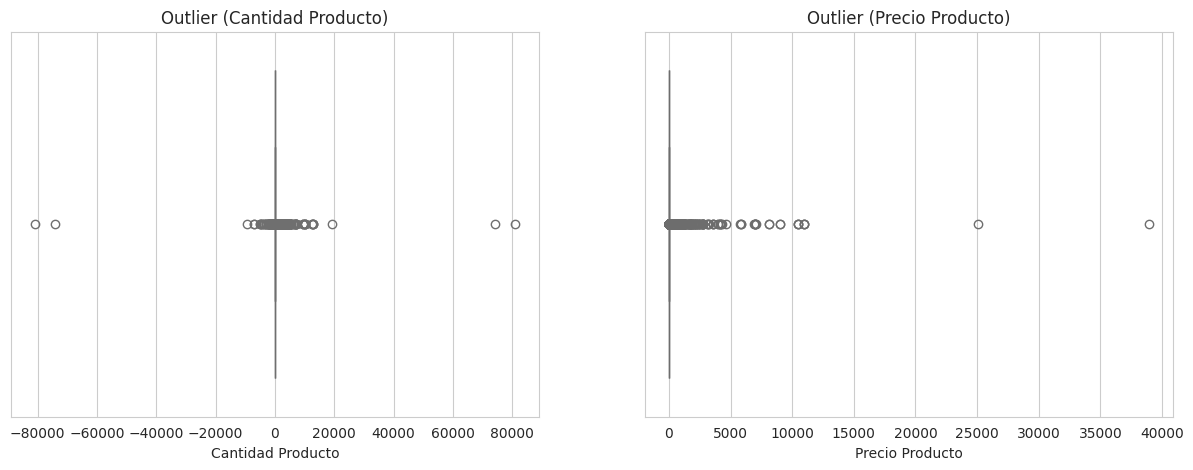

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Quantity (Cantidad)
sns.boxplot(x=df_limpio['Quantity'], ax=ax[0], color='skyblue')
ax[0].set_title('Outlier (Cantidad Producto)')
ax[0].set_xlabel('Cantidad Producto')

# Gráfico 2: Price (Precio)
sns.boxplot(x=df_limpio['Price'], ax=ax[1], color='salmon')
ax[1].set_title('Outlier (Precio Producto)')
ax[1].set_xlabel('Precio Producto')

plt.show()

El análisis de la variable `Quantity` detectó valores atípicos vinculados a cuatro transacciones excepcionales, que corresponden a compras masivas o cancelaciones totales.

Respecto ` Price ` (Precio unitario) dos productos cuyos costes exceden considerablemente los límites establecidos. Para mantener la representatividad de la muestra y enfocarnos en un segmento de mercado de precios competitivos, se procederá a eliminar estos registros del conjunto de datos.

Vamos a eliminar los valores atípicos utilizamos el método del **Rango Intercuartílico**.

In [ ]:
Q1 = df['Quantity'].quantile(0.25)          # 1. Calcular Cuartiles
Q3 = df['Quantity'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR             # 2. Definir límites
limite_superior = Q3 + 1.5 * IQR

# 3. Detectar quién se pasa
outliers1 = df_limpio[df_limpio['Quantity'] > limite_superior]
outliers2 = df_limpio[df_limpio['Quantity'] < limite_inferior]
df_limpio.drop(outliers1.index, inplace=True)
df_limpio.drop(outliers2.index, inplace=True)

In [ ]:
Q1 = df['Price'].quantile(0.25)          # 1. Calcular Cuartiles
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR         # 2. Definir límites
limite_superior = Q3 + 1.5 * IQR

# 3. Detectar quién se pasa
outliers1 = df_limpio[df_limpio['Price'] > limite_superior]
outliers2 = df_limpio[df_limpio['Price'] < limite_inferior]
df_limpio.drop(outliers1.index, inplace=True)
df_limpio.drop(outliers2.index, inplace=True)

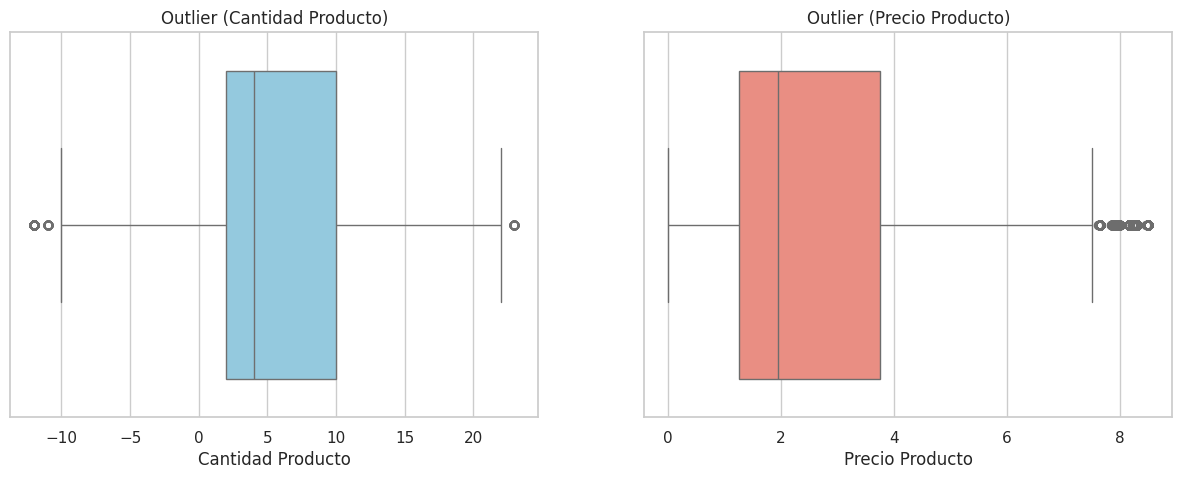

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Quantity (Cantidad)
sns.boxplot(x=df_limpio['Quantity'], ax=ax[0], color='skyblue')
ax[0].set_title('Outlier (Cantidad Producto)')
ax[0].set_xlabel('Cantidad Producto')

# Gráfico 2: Price (Precio)
sns.boxplot(x=df_limpio['Price'], ax=ax[1], color='salmon')
ax[1].set_title('Outlier (Precio Producto)')
ax[1].set_xlabel('Precio Producto')

plt.show()

### **2.32 Variables Categóricas(Cualitativa)**

In [ ]:
df_limpio.describe(include='object').T

,count,unique,top,freq
Invoice,651913,38869,576339,485
StockCode,651913,4342,85123A,4089
Description,651913,4917,WHITE HANGING HEART T-LIGHT HOLDER,4083
InvoiceDate,651913,36313,2011-11-14 15:27:00,485
Country,651913,41,United Kingdom,594960


* `Invoice`:
Hay 44.876 números de factura únicos. El número de factura más frecuente es 573585, que aparece 542 veces, lo que posiblemente representa una transacción grande o un pedido con múltiples artículos.
* `StockCode`:
Hay 4.646 códigos de producto únicos que representan diferentes artículos.
El código de producto más frecuente es 85123A, que aparece 5156 veces en el conjunto de datos.
* `Description`:
Hay 41.439 descripciones de productos únicas. La descripción de producto más frecuente es "WHITE HANGING HEART T-LIGHT HOLDER", que aparece 5.149 veces.
* `Country`:
Las transacciones provienen de 41 países diferentes, con una clara mayoría de las transacciones originadas en el Reino Unido.

### **2.33 Visualización Exploratoria**
### **Histograma**

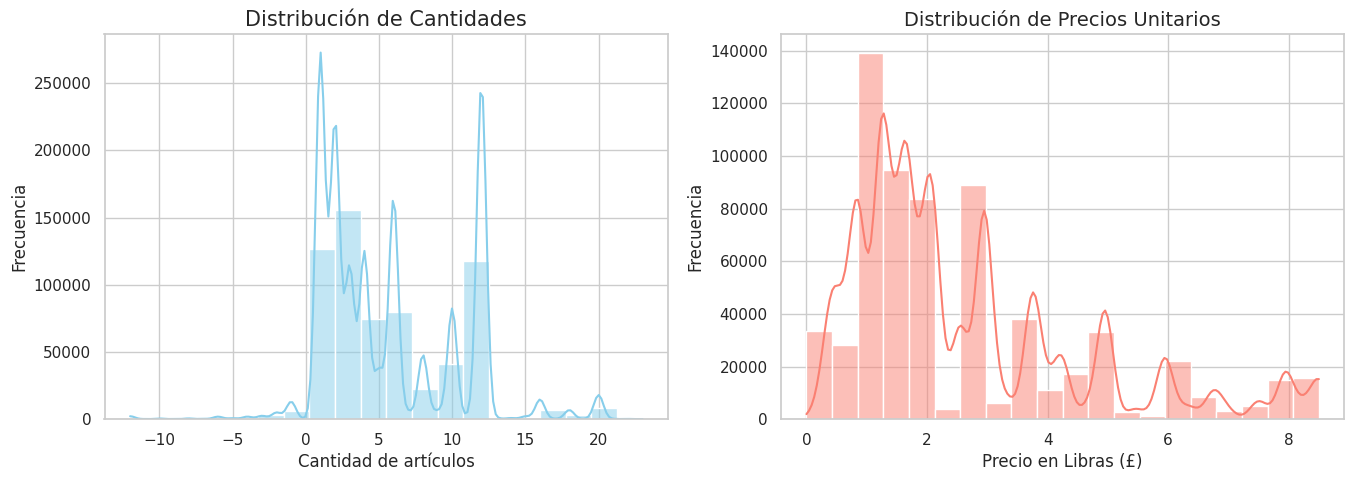

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# 1. Histograma de Cantidad (Quantity)
sns.histplot(x=df_limpio['Quantity'], bins=20, color='skyblue', kde=True, ax=axes[0])
axes[0].set_title('Distribución de Cantidades', fontsize=15)
axes[0].set_xlabel('Cantidad de artículos', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)

# 2. Histograma de Precio Unitario (Price)
sns.histplot(x=df_limpio['Price'], bins=20, color='salmon', kde=True, ax=axes[1])
axes[1].set_title('Distribución de Precios Unitarios', fontsize=14)
axes[1].set_xlabel('Precio en Libras (£)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)

plt.show()

## **2.3 Análisis de Correlación: ¿Cómo se relacionan las variables entre sí?**



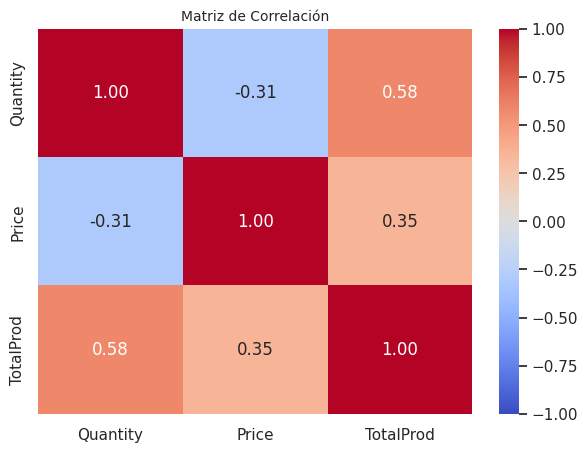

In [ ]:
# 1. Calculamos la matriz de correlación
cols_interes = ['Quantity',	'Price', 'TotalProd']
matriz_corr = df_limpio[cols_interes].corr()
plt.figure(figsize=(7, 5))
# 2. Dibujamos el Heatmap
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Matriz de Correlación', fontsize=10)
plt.show()

- La correlación más fuerte será entre `Quantity` y `TotalProd`. Esto confirma que el dinero de la tienda viene de vender **muchas** unidades, más que de vender artículos caros.

- El gasto total de tus clientes está "atado" a cuántas cosas meten en el carrito, no tanto al precio individual de los productos.

- La correlación baja entre `Price` y `Quantity` sugiere que tus clientes no compran menos solo porque el producto sea más caro (típico de mayoristas que necesitan el stock sin importar variaciones pequeñas de precio).

## **2.4 Análisis Temporal: Tendencias de ventas o registros a lo largo del tiempo.**
### **Producto más y menos caro**


In [ ]:
df_limpio.loc[df_limpio['Price'].idxmax()]   # Producto mas caro


,22
Invoice,489436
StockCode,22194
Description,BLACK DINER WALL CLOCK
Quantity,2
InvoiceDate,2009-12-01 09:06:00
Price,8.5
Customer ID,13078
Country,United Kingdom
InvoiceDate_DT,2009-12-01 09:06:00
Estado,1


In [ ]:
df_limpio.loc[df_limpio['Price'].idxmin()]   # producto mas barato

,4674
Invoice,489825
StockCode,22076
Description,6 RIBBONS EMPIRE
Quantity,12
InvoiceDate,2009-12-02 13:34:00
Price,0.0
Customer ID,16126
Country,United Kingdom
InvoiceDate_DT,2009-12-02 13:34:00
Estado,1


### **Top 10 clientes de Alto y de Bajo Volumen**

In [ ]:
clientes = df_limpio.groupby(['Customer ID', 'Country'], as_index=False)['TotalProd'].sum()  # Más compran
clientes.sort_values('TotalProd', ascending=False).head(10)


,Customer ID,Country,TotalProd
2461,14911,EIRE,155742.03
5272,17841,United Kingdom,50197.30
719,13089,United Kingdom,48812.30
1732,14156,EIRE,48115.81
5280,17850,United Kingdom,47644.62
1676,14096,United Kingdom,38289.06
711,13081,United Kingdom,29932.77
2849,15311,United Kingdom,29434.70
396,12748,United Kingdom,29329.81
1870,14298,United Kingdom,27509.19


In [ ]:
clientes.sort_values('TotalProd').head(10)   # Menos compran

,Customer ID,Country,TotalProd
1906,14337,United Kingdom,-547.23
721,13091,United Kingdom,-313.53
3278,15767,United Kingdom,-217.20
3439,15935,United Kingdom,-103.36
4323,16853,United Kingdom,-67.50
5096,17661,United Kingdom,-54.00
2417,14864,United Kingdom,-48.75
5188,17755,United Kingdom,-44.38
4767,17313,United Kingdom,-40.71
3061,15538,United Kingdom,-36.65


### **2.5 Conclusiones del Análisis**
- Se identificó una base de datos robusta pero con una presencia significativa de registros **duplicados**. Tras una limpieza, se optó por eliminar las filas que contuvieran los valores nulos en columnas críticas como la descripción del producto y el ID del cliente. Basándonos en que dichos campos son identificadores únicos no imputables, por lo que su ausencia comprometería la integridad del análisis.

- Se observa que la gran mayoría de las transacciones fueron **completadas** con éxito, con una tasa de cancelaciones baja. El hallazgo de que el producto más costoso 'BLACK DINER WALL CLOCK' tiene un valor unitario de apenas 8.5 confirma que estamos ante una empresa de **comercio minorista**. Su rentabilidad no reside en el margen de beneficio por objeto, sino en el alto volumen de ventas.

- Gracias a la conversión de los datos a formato `datetime64[ns]`, el dataset está optimizado para realizar estudios avanzados de comportamiento. Esto permite vincular el ID del cliente con sus ciclos de compra y aplicar modelos de estacionalidad para identificar con precisión los periodos de mayor flujo transaccional.



## **3. Aprendizaje no supervisado**

Aplicamos el algoritmo K-means para segmentar a los clientes de una empresa de ventas en función de su demografía.

## **Frequency Encoding (Codificación por Frecuencia)**

El Frequency Encoding convierte las etiquetas geográficas en valores numéricos proporcionales a su frecuencia. De este modo, se facilita que el algoritmo interprete la relevancia de cada región, asignando valores altos a los mercados principales y valores cercanos a cero a los mercados marginales.


In [ ]:
# 1. Creamos el diccionario de frecuencias (proporciones)
frecuencia_paises = df_limpio['Country'].value_counts(normalize=True)

# 2. Mapeamos la frecuencia a una nueva columna cuantitativa
df_limpio['Country_Freq'] = df_limpio['Country'].map(frecuencia_paises)

In [ ]:
# 3. Resultado: El UK tendrá un valor de ~0.90, Germany ~0.02, etc.
print(df_limpio[['Country', 'Country_Freq']].head())

          Country  Country_Freq
0  United Kingdom      0.912637
1  United Kingdom      0.912637
2  United Kingdom      0.912637
7  United Kingdom      0.912637
8  United Kingdom      0.912637


## **3.1 Transformación y Escalado**
En primer lugar, eliminamos los valores negativos (cancelaciones).


In [ ]:
df_kmeans = df_limpio[df_limpio['Quantity'] > 0]


Partimos de una columna Country_Freq con valores normalizados entre 0 y 1, junto con la variable que representa la cantidad de productos. Antes de ejecutar el algoritmo K-means, es necesario escalar ambas variables.

Utilizaremos **StandardScaler** para que ambas variables tengan una media de 0 y una desviación estándar de 1. Así, ambas tendrán el mismo peso en la segmentación.

In [ ]:
X = df_kmeans[['Country_Freq', 'Quantity']]    # Variables para el modelo
scaler = StandardScaler()                      # Escalamos los datos
X_scaled = scaler.fit_transform(X)

# Ahora X_scaled es una matriz lista para el algoritmo
print(X_scaled[:5])

[[0.30727041 1.36401607]
 [0.30727041 1.36401607]
 [0.30727041 1.36401607]
 [0.30727041 0.92892227]
 [0.30727041 1.36401607]]


## **3.2 Aplicamos el K-means**
 Agrupamos los datos en  k  grupos, intentando que los miembros de un grupo se parezcan mucho entre sí y poco a los de otros grupos.

 En primer lugar, aplicamos el **Método del Codo (Elbow Method)** para saber específicamente cuántos numeros de clusters usamos. Si la curva parece un brazo, el "codo" es el punto exacto donde la caída se suaviza.

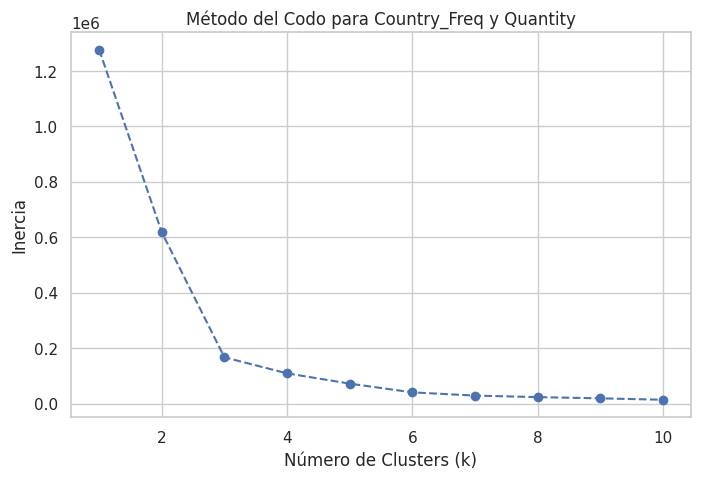

In [ ]:
# Lista para guardar los valores de inercia
inercia = []
rango_k = range(1, 11) # Probamos de 1 a 10 clusters

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

# Graficamos los resultados
plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercia, marker='o', linestyle='--')
plt.title('Método del Codo para Country_Freq y Quantity')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.show()

Aplicamos el K-means con un n_clusters = 3 :

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)    # Aplicamos K-Means

# Guardamos la etiqueta del cluster en nuestro dataframe original
X['cluster'] = kmeans.fit_predict(X_scaled)
print(X)

         Country_Freq  Quantity  cluster
0            0.912637        12        2
1            0.912637        12        2
2            0.912637        12        2
7            0.912637        10        2
8            0.912637        12        2
...               ...       ...      ...
1067365      0.015910        12        1
1067366      0.015910         6        1
1067367      0.015910         4        1
1067368      0.015910         4        1
1067369      0.015910         3        1

[638251 rows x 3 columns]


/tmp/ipython-input-4127962259.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['cluster'] = kmeans.fit_predict(X_scaled)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


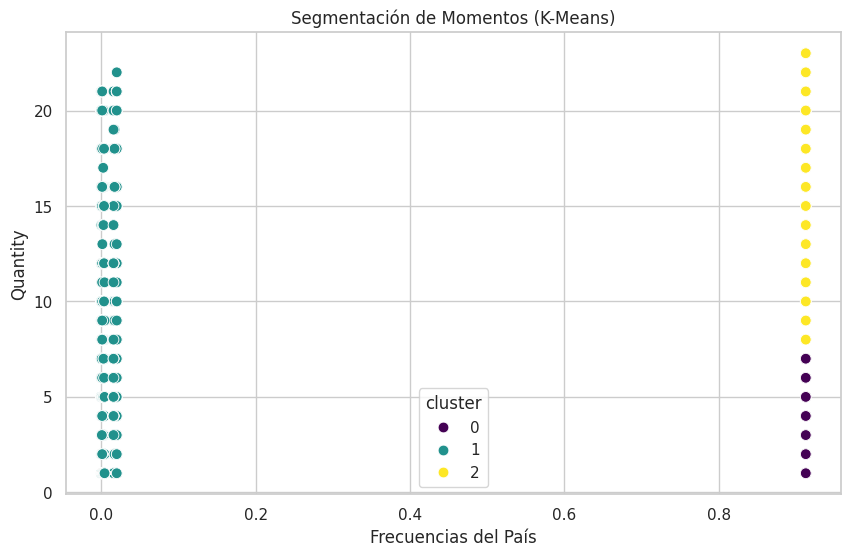

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=X['Country_Freq'],
                y=X['Quantity'],
                hue=X['cluster'], palette='viridis', s=60)

plt.title('Segmentación de Momentos (K-Means)')
plt.xlabel('Frecuencias del País')
plt.ylabel('Quantity')
plt.show()

Asimismo,para que el análisis sea más potente, se calculan los **centroides** para ponerle nombre a tus clusters:

In [ ]:
# Agrupar por cluster para ver los valores medios para la interpretación
cluster_analysis = X.groupby('cluster').mean().round(2)

# Añadir una columna de conteo para ver cuántos clientes hay en cada grupo
cluster_analysis['Count'] = X['cluster'].value_counts()
print(cluster_analysis)

         Country_Freq  Quantity   Count
cluster                                
0                0.91      2.87  411608
1                0.01      8.41   55066
2                0.91     11.74  171577


### **Interpretación de los perfiles de clientes a partir de los centroides**

A partir de los centroides obtenidos por K-means, se identifican tres perfiles claramente diferenciados en función de la frecuencia del país `Country_Freq` y la cantidad de productos adquiridos `Quantity`:

**Cluster 0 : Mercado de bajo volumen**
- Country_Freq ≈ **0.91**
- Quantity ≈ **2.87**
- Número de observaciones: **411.608**

Representa a la mayoría de los clientes, procedentes de países muy frecuentes en el dataset (principalmente el Reino Unido).
Sin embargo, su volumen de compra es relativamente bajo esto indica un comportamiento de ***compras pequeñas*** y ***recurrentes***.

**Cluster 1 : Mercado poco frecuente de alto volumen**
- Country_Freq ≈ **0.01**
- Quantity ≈ **8.41**
- Número de observaciones: **55.066**

Este cluster agrupa a clientes de países con muy baja representación en el conjunto de datos. A pesar de ser minoritarios, realizan compras de volumen considerable.
Su comportamiento sugiere clientes ***internacionales específicos***, posiblemente ***distribuidores*** o compradores ***ocasionales*** de gran tamaño.

**Cluster 2 : Mercado de alto volumen**
- Country_Freq ≈ **0.91**
- Quantity ≈ **11.74**
- Número de observaciones: **171.577**

Aunque no es el grupo más numeroso corresponde a clientes del mercado principal que realizan pedidos grandes. Este cluster suele asociarse a clientes de alto valor, como ***mayoristas*** o compradores ***recurrentes con elevada demanda***.


### **Conclusión generales**
Los resultados muestran que la **frecuencia geográfica** no solo diferencia mercados principales y secundarios, sino que, combinada con el volumen de compra permite distinguir entre clientes masivos de bajo volumen y clientes estratégicos de alto volumen.
Esta segmentación resulta especialmente útil para diseñar estrategias diferenciadas de precios, logística o fidelización.